In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files

uploaded = files.upload()

Saving usage_data.csv to usage_data.csv
Saving customer_info.csv to customer_info.csv
Saving churn_labels.csv to churn_labels.csv


In [5]:
usage_data = pd.read_csv("usage_data.csv")

customer_info = pd.read_csv("customer_info.csv")




In [6]:
print("Usage data:")
print(usage_data.shape)

print("\nCustomer info:")
print(customer_info.shape)

Usage data:
(120000, 6)

Customer info:
(10200, 7)


In [7]:
print("Columnas de usage_data:")
print(usage_data.columns.tolist())

print("\nColumnas de customer_info:")
print(customer_info.columns.tolist())

Columnas de usage_data:
['CustomerID', 'Month', 'CallMinutes', 'DataUsageGB', 'SMSCount', 'Complaints']

Columnas de customer_info:
['CustomerID', 'Age', 'Gender', 'Region', 'ContractType', 'MonthlyCharges', 'SignupDate']


In [8]:
print("Primeras 5 filas de usage_data:")
display(usage_data.head())

print("\nPrimeras 5 filas de customer_info:")
display(customer_info.head())

Primeras 5 filas de usage_data:


,CustomerID,Month,CallMinutes,DataUsageGB,SMSCount,Complaints
0,CUST_0,2023-01-31,518.12,7.21,9,1
1,CUST_0,2023-02-28,439.79,5.99,35,1
2,CUST_0,2023-03-31,545.06,14.16,14,1
3,CUST_0,2023-04-30,461.78,6.66,40,0
4,CUST_0,2023-05-31,434.82,12.75,26,2



Primeras 5 filas de customer_info:


,CustomerID,Age,Gender,Region,ContractType,MonthlyCharges,SignupDate
0,CUST_0,NaN,Male,Urban,Yearly,48.18,2021-03-20
1,CUST_1,NaN,Female,Suburban,Prepaid,38.94,2020-01-25
2,CUST_2,46.0,Female,Rural,Monthly,48.56,2022-08-31
3,CUST_3,NaN,Female,Urban,Prepaid,24.22,2018-12-09
4,CUST_4,60.0,Male,Rural,Monthly,67.86,2022-12-28


In [9]:
print("Información de usage_data:")
usage_data.info()

print("\n" + "="*60 + "\n")

print("Información de customer_info:")
customer_info.info()

Información de usage_data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CustomerID   120000 non-null  object 
 1   Month        120000 non-null  object 
 2   CallMinutes  120000 non-null  float64
 3   DataUsageGB  120000 non-null  float64
 4   SMSCount     120000 non-null  int64  
 5   Complaints   120000 non-null  int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 5.5+ MB


Información de customer_info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      10200 non-null  object 
 1   Age             6617 non-null   float64
 2   Gender          10200 non-null  object 
 3   Region          10200 non-null  object 
 4   ContractType    10200 non-null  object 
 5

In [10]:
print("Valores faltantes en usage_data:")
print(usage_data.isnull().sum())

print("\n" + "="*60 + "\n")

print("Valores faltantes en customer_info:")
print(customer_info.isnull().sum())

Valores faltantes en usage_data:
CustomerID     0
Month          0
CallMinutes    0
DataUsageGB    0
SMSCount       0
Complaints     0
dtype: int64


Valores faltantes en customer_info:
CustomerID           0
Age               3583
Gender               0
Region               0
ContractType         0
MonthlyCharges       0
SignupDate           0
dtype: int64


In [11]:
print("Filas duplicadas en usage_data:")
print(usage_data.duplicated().sum())

print("\nFilas duplicadas en customer_info:")
print(customer_info.duplicated().sum())

print("\nCustomerID duplicados en usage_data:")
print(usage_data["CustomerID"].duplicated().sum())

print("\nCustomerID duplicados en customer_info:")
print(customer_info["CustomerID"].duplicated().sum())

Filas duplicadas en usage_data:
0

Filas duplicadas en customer_info:
195

CustomerID duplicados en usage_data:
110000

CustomerID duplicados en customer_info:
200


In [12]:
duplicated_customers = customer_info[
    customer_info["CustomerID"].duplicated(keep=False)
].sort_values("CustomerID")

display(duplicated_customers)

,CustomerID,Age,Gender,Region,ContractType,MonthlyCharges,SignupDate
1031,CUST_1031,57.0,Male,Urban,Monthly,40.60,2023-05-23
10070,CUST_1031,57.0,Male,Urban,Monthly,40.60,2023-05-23
1042,CUST_1042,NaN,Male,Urban,Monthly,63.09,2021-04-24
10075,CUST_1042,NaN,Male,Urban,Monthly,63.09,2021-04-24
10061,CUST_1128,55.0,Male,Urban,Prepaid,31.88,2019-01-18
...,...,...,...,...,...,...,...
10111,CUST_9881,36.0,Male,Suburban,Yearly,56.38,2018-02-04
10096,CUST_9977,NaN,Male,Urban,Monthly,34.32,2020-03-22
9977,CUST_9977,NaN,Male,Urban,Monthly,34.32,2020-03-22
999,CUST_999,55.0,Female,Urban,Prepaid,37.78,2021-04-16


Tenemos 400 filas correspondientes a 200 CustomerID duplicados, es decir, cada uno de esos 200 clientes aparece exactamente dos veces.

In [13]:
# Contar cuántos registros tiene cada CustomerID
customer_counts = customer_info["CustomerID"].value_counts()

# Mostrar los CustomerID que aparecen más de una vez
duplicated_ids = customer_counts[customer_counts > 1]

print("Cantidad de CustomerID duplicados:", len(duplicated_ids))
print("\nDistribución de cantidad de registros por cliente:")
print(duplicated_ids.value_counts())

Cantidad de CustomerID duplicados: 200

Distribución de cantidad de registros por cliente:
count
2    200
Name: count, dtype: int64


Eso significaría que los 200 clientes aparecen exactamente 2 veces, sin clientes con 3 o más registros.

Después de comprobarlo, se realizara una limpieza segura de customer_info y dejar un solo registro por cliente.

In [14]:
customer_info = customer_info.drop_duplicates(
    subset="CustomerID",
    keep="first"
).reset_index(drop=True)

print("Filas después de eliminar duplicados:", len(customer_info))
print("CustomerID únicos:", customer_info["CustomerID"].nunique())

Filas después de eliminar duplicados: 10000
CustomerID únicos: 10000


In [15]:
print("Estadísticas de usage_data:")
display(usage_data.describe())

print("\n" + "="*60 + "\n")

print("Estadísticas de customer_info:")
display(customer_info.describe())

Estadísticas de usage_data:


,CallMinutes,DataUsageGB,SMSCount,Complaints
count,120000.000000,120000.000000,120000.000000,120000.000000
mean,492.401958,9.898117,24.525392,0.503000
std,117.443986,3.067815,14.423944,0.708763
min,34.140000,0.000000,0.000000,0.000000
25%,418.450000,7.810000,12.000000,0.000000
50%,494.960000,9.920000,25.000000,0.000000
75%,571.080000,11.980000,37.000000,1.000000
max,914.160000,22.730000,49.000000,6.000000




Estadísticas de customer_info:


,Age,MonthlyCharges
count,6500.000000,10000.000000
mean,43.419385,51.000240
std,14.967374,21.543385
min,18.000000,-6.720000
25%,31.000000,39.797500
50%,43.000000,50.015000
75%,56.000000,60.500000
max,69.000000,390.300000


usage_data

Los rangos parecen razonables:

CallMinutes: 34.14 → 914.16
DataUsageGB: 0 → 22.73 GB
SMSCount: 0 → 49
Complaints: 0 → 6

No vemos, por ahora, valores negativos o evidentemente imposibles.

customer_info

Age

Mínimo: 18
Máximo: 69
Valores faltantes: 3.500

El rango de edad es coherente

MonthlyCharges 🚨

Mínimo: -6.72
Máximo: 390.30

Aquí sí tenemos valores sospechosos. Un cargo mensual negativo no tiene sentido en este contexto. Y 390.30 también merece una revisión porque está bastante alejado de la media (~51).

In [16]:
# Valores negativos en MonthlyCharges
negative_charges = customer_info[customer_info["MonthlyCharges"] < 0]

print("Cantidad de MonthlyCharges negativos:", len(negative_charges))

print("\nRegistros con MonthlyCharges negativos:")
display(negative_charges)

Cantidad de MonthlyCharges negativos: 5

Registros con MonthlyCharges negativos:


,CustomerID,Age,Gender,Region,ContractType,MonthlyCharges,SignupDate
4671,CUST_4671,56.0,Male,Rural,Prepaid,-3.89,2020-11-12
5575,CUST_5575,39.0,Female,Suburban,Monthly,-0.46,2023-02-01
6820,CUST_6820,60.0,Male,Urban,Yearly,-3.15,2018-02-09
8567,CUST_8567,36.0,Male,Rural,Prepaid,-6.72,2018-04-17
9403,CUST_9403,19.0,Male,Rural,Monthly,-4.55,2023-05-18


Hay 5 valores negativos, y no parecen ser un caso de una categoría específica, aparecen en distintos tipos de contrato, regiones y edades. Por tratarse de cargos mensuales, los valores negativos son inconsistentes con la variable.

El IQR nos permite identificar estadísticamente qué valores se alejan del comportamiento central de los datos. Luego veremos esos registros y decidiremos si son:errores, valores legítimos pero extremos o datos que necesitan tratamiento.

In [17]:
# Calcular Q1, Q3 e IQR de MonthlyCharges
Q1 = customer_info["MonthlyCharges"].quantile(0.25)
Q3 = customer_info["MonthlyCharges"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", lower_bound)
print("Límite superior:", upper_bound)

# Identificar valores fuera de los límites
outliers_charges = customer_info[
    (customer_info["MonthlyCharges"] < lower_bound) |
    (customer_info["MonthlyCharges"] > upper_bound)
]

print("\nCantidad de posibles outliers:", len(outliers_charges))

display(outliers_charges.sort_values("MonthlyCharges"))

Q1: 39.7975
Q3: 60.5
IQR: 20.7025
Límite inferior: 8.743749999999999
Límite superior: 91.55375000000001

Cantidad de posibles outliers: 111


,CustomerID,Age,Gender,Region,ContractType,MonthlyCharges,SignupDate
8567,CUST_8567,36.0,Male,Rural,Prepaid,-6.72,2018-04-17
9403,CUST_9403,19.0,Male,Rural,Monthly,-4.55,2023-05-18
4671,CUST_4671,56.0,Male,Rural,Prepaid,-3.89,2020-11-12
6820,CUST_6820,60.0,Male,Urban,Yearly,-3.15,2018-02-09
5575,CUST_5575,39.0,Female,Suburban,Monthly,-0.46,2023-02-01
...,...,...,...,...,...,...,...
988,CUST_988,31.0,Male,Rural,Prepaid,353.35,2022-12-25
5772,CUST_5772,35.0,Male,Urban,Monthly,356.00,2023-06-09
3666,CUST_3666,21.0,Male,Urban,Prepaid,367.65,2021-09-09
9404,CUST_9404,NaN,Male,Urban,Monthly,369.55,2019-11-19



El IQR identifica 111 posibles outliers. sin embargo, no significa que los 111 sean errores.

El límite estadístico superior es aproximadamente 91.55 y tenemos valores que llegan hasta 390.30.

Eso nos plantea dos grupos diferentes:

Los 5 valores negativos: son claramente inválidos para un cargo mensual.
Los valores superiores a 91.55 : son valores extremos estadísticamente, pero podrían ser cargos reales. No debemos eliminarlos solo por ser outliers.

Esto es importante porque un outlier no es automáticamente un error.


In [18]:
# Analizar los posibles outliers superiores
high_charges = customer_info[
    customer_info["MonthlyCharges"] > upper_bound
]

print("Cantidad de cargos superiores al límite:", len(high_charges))

print("\nCargos altos por tipo de contrato:")
display(
    high_charges["ContractType"]
    .value_counts()
    .to_frame("Cantidad")
)

print("\nCargos altos por región:")
display(
    high_charges["Region"]
    .value_counts()
    .to_frame("Cantidad")
)

print("\nEstadísticas de los cargos altos:")
display(high_charges["MonthlyCharges"].describe())

Cantidad de cargos superiores al límite: 82

Cargos altos por tipo de contrato:


,Cantidad
ContractType,
Monthly,36
Prepaid,28
Yearly,18



Cargos altos por región:


,Cantidad
Region,
Rural,40
Suburban,23
Urban,19



Estadísticas de los cargos altos:


,MonthlyCharges
count,82.000000
mean,193.902927
std,94.064740
min,91.810000
25%,97.467500
50%,189.175000
75%,281.437500
max,390.300000


Hay 82 cargos superiores a $91,55, pero no están concentrados exclusivamente en un tipo de contrato o región. Además, el promedio de ese grupo es 193,90, con valores que llegan a 390,30.

Quiero comprobar si los cargos altos están relacionados con algún patrón en el tipo de contrato. Por ejemplo, sería perfectamente posible que un contrato Yearly o algún segmento específico tenga cargos más altos.

In [19]:
print("MonthlyCharges por tipo de contrato:")
display(
    customer_info.groupby("ContractType")["MonthlyCharges"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("\n" + "="*60 + "\n")

print("MonthlyCharges por región:")
display(
    customer_info.groupby("Region")["MonthlyCharges"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

MonthlyCharges por tipo de contrato:


,count,mean,median,min,max
ContractType,,,,,
Monthly,3953,50.84,49.70,-4.55,369.55
Prepaid,4041,51.09,50.08,-6.72,390.30
Yearly,2006,51.12,50.39,-3.15,321.45




MonthlyCharges por región:


,count,mean,median,min,max
Region,,,,,
Rural,3311,51.35,49.89,-6.72,353.35
Suburban,3402,50.88,50.03,-0.46,390.30
Urban,3287,50.77,50.07,-3.15,369.55


Las medianas están prácticamente alrededor de 50 en todos los grupos:

Monthly → 49.70
Prepaid → 50.08
Yearly → 50.39

Y por región:

Rural → 49.89
Suburban → 50.03
Urban → 50.07

Es decir, los cargos altos no parecen corresponder a una categoría completa de contrato o región. Son casos individuales/extremos dentro de cada grupo.

In [20]:
# Convertir columnas de fecha a formato datetime
usage_data["Month"] = pd.to_datetime(usage_data["Month"])
customer_info["SignupDate"] = pd.to_datetime(customer_info["SignupDate"])

# Verificar los nuevos tipos de datos
print("Tipo de Month:", usage_data["Month"].dtype)
print("Tipo de SignupDate:", customer_info["SignupDate"].dtype)

Tipo de Month: datetime64[ns]
Tipo de SignupDate: datetime64[ns]


Ahora voy a tratar los 5 MonthlyCharges negativos. Como ya se comprobo que son valores inválidos y son muy pocos, no conviene eliminar clientes completos porque se pierde información útil de esos clientes.

Una estrategia sencilla y defendible para este proyecto es reemplazar esos 5 valores por la mediana de MonthlyCharges de su mismo ContractType. Así evitamos que los valores extremos influyan en la imputación y respetamos las diferencias entre tipos de contrato.


In [21]:
# Guardar los valores originales de los cargos negativos
negative_charges = customer_info[customer_info["MonthlyCharges"] < 0].copy()

# Calcular la mediana de MonthlyCharges por tipo de contrato
contract_medians = customer_info.groupby("ContractType")["MonthlyCharges"].median()

print("Mediana de MonthlyCharges por tipo de contrato:")
display(contract_medians)

print("\nValores negativos que vamos a corregir:")
display(
    negative_charges[["CustomerID", "ContractType", "MonthlyCharges"]]
)

Mediana de MonthlyCharges por tipo de contrato:


,MonthlyCharges
ContractType,
Monthly,49.70
Prepaid,50.08
Yearly,50.39



Valores negativos que vamos a corregir:


,CustomerID,ContractType,MonthlyCharges
4671,CUST_4671,Prepaid,-3.89
5575,CUST_5575,Monthly,-0.46
6820,CUST_6820,Yearly,-3.15
8567,CUST_8567,Prepaid,-6.72
9403,CUST_9403,Monthly,-4.55


se tiene las medianas y podemos hacer la corrección de forma reproducible.

Los reemplazos serán:

CUST_4671 → 50.08 (Prepaid)
CUST_5575 → 49.70 (Monthly)
CUST_6820 → 50.39 (Yearly)
CUST_8567 → 50.08 (Prepaid)
CUST_9403 → 49.70 (Monthly)

In [22]:
# Reemplazar los valores negativos por la mediana de su tipo de contrato
customer_info.loc[
    customer_info["MonthlyCharges"] < 0,
    "MonthlyCharges"
] = customer_info.loc[
    customer_info["MonthlyCharges"] < 0,
    "ContractType"
].map(contract_medians)

# Verificar que ya no existan valores negativos
print(
    "Valores negativos después de la corrección:",
    (customer_info["MonthlyCharges"] < 0).sum()
)

# Verificar los registros corregidos
display(
    customer_info[
        customer_info["CustomerID"].isin(negative_charges["CustomerID"])
    ][["CustomerID", "ContractType", "MonthlyCharges"]]
)

Valores negativos después de la corrección: 0


,CustomerID,ContractType,MonthlyCharges
4671,CUST_4671,Prepaid,50.08
5575,CUST_5575,Monthly,49.70
6820,CUST_6820,Yearly,50.39
8567,CUST_8567,Prepaid,50.08
9403,CUST_9403,Monthly,49.70


Ahora MonthlyCharges ya no tiene valores negativos y no se elimino ningún cliente. Además, se realiza una transformación que podemos justificar en el informe, imputación mediante la mediana del tipo de contrato.

In [23]:
print("Edad por género:")
display(
    customer_info.groupby("Gender")["Age"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("\n" + "="*60 + "\n")

print("Edad por región:")
display(
    customer_info.groupby("Region")["Age"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("\n" + "="*60 + "\n")

print("Edad por tipo de contrato:")
display(
    customer_info.groupby("ContractType")["Age"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

Edad por género:


,count,mean,median,min,max
Gender,,,,,
Female,3219,43.19,43.0,18.0,69.0
Male,3281,43.64,44.0,18.0,69.0




Edad por región:


,count,mean,median,min,max
Region,,,,,
Rural,2162,43.40,43.0,18.0,69.0
Suburban,2201,43.76,44.0,18.0,69.0
Urban,2137,43.09,43.0,18.0,69.0




Edad por tipo de contrato:


,count,mean,median,min,max
ContractType,,,,,
Monthly,2586,43.29,43.0,18.0,69.0
Prepaid,2610,43.53,44.0,18.0,69.0
Yearly,1304,43.45,43.0,18.0,69.0


Las diferencias entre grupos son muy pequeñas:

Por género: medianas de 43 y 44 años.
Por región: 43, 44 y 43.
Por contrato: 43, 44 y 43.

No hay una diferencia suficientemente grande, podemos usar la mediana global de Age, que es robusta frente a valores extremos y mantiene las edades dentro del rango observado.

In [24]:
age_median = customer_info["Age"].median()

print("Mediana global de Age:", age_median)
print("Valores faltantes antes de imputar:", customer_info["Age"].isnull().sum())

Mediana global de Age: 43.0
Valores faltantes antes de imputar: 3500


In [25]:
# Imputar los valores faltantes de Age con la mediana global
customer_info["Age"] = customer_info["Age"].fillna(age_median)

# Verificar el resultado
print("Valores faltantes en Age después de la imputación:",
      customer_info["Age"].isnull().sum())

print("Mediana de Age utilizada:", age_median)

Valores faltantes en Age después de la imputación: 0
Mediana de Age utilizada: 43.0


Age sin valores faltantes, y se uso la mediana global de 43 años

In [26]:
# Verificación general de valores faltantes
print("=== VALORES FALTANTES ===")
print("\nUsage data:")
print(usage_data.isnull().sum())

print("\nCustomer info:")
print(customer_info.isnull().sum())


# Verificación de duplicados
print("\n=== DUPLICADOS ===")
print("Duplicados completos en usage_data:",
      usage_data.duplicated().sum())

print("Duplicados completos en customer_info:",
      customer_info.duplicated().sum())

print("\nCustomerID únicos en usage_data:",
      usage_data["CustomerID"].nunique())

print("CustomerID únicos en customer_info:",
      customer_info["CustomerID"].nunique())

=== VALORES FALTANTES ===

Usage data:
CustomerID     0
Month          0
CallMinutes    0
DataUsageGB    0
SMSCount       0
Complaints     0
dtype: int64

Customer info:
CustomerID        0
Age               0
Gender            0
Region            0
ContractType      0
MonthlyCharges    0
SignupDate        0
dtype: int64

=== DUPLICADOS ===
Duplicados completos en usage_data: 0
Duplicados completos en customer_info: 0

CustomerID únicos en usage_data: 10000
CustomerID únicos en customer_info: 10000


se obtiene:

Cero valores faltantes en ambas tablas.

Cero duplicados completos.

10.000 clientes únicos en customer_info.

usage_data también corresponde a esos 10.000 clientes.

Las fechas ya están en formato correcto.

Corregimos los MonthlyCharges negativos.

Los valores altos de MonthlyCharges los conservamos porque pueden representar casos reales.

In [27]:
# Verificar que todos los CustomerID de usage_data
# existan en customer_info

usage_customers = set(usage_data["CustomerID"])
customer_info_customers = set(customer_info["CustomerID"])

missing_in_customer_info = usage_customers - customer_info_customers
missing_in_usage_data = customer_info_customers - usage_customers

print("Clientes en usage_data:", len(usage_customers))
print("Clientes en customer_info:", len(customer_info_customers))

print("\nClientes de usage_data que NO están en customer_info:",
      len(missing_in_customer_info))

print("Clientes de customer_info que NO están en usage_data:",
      len(missing_in_usage_data))

Clientes en usage_data: 10000
Clientes en customer_info: 10000

Clientes de usage_data que NO están en customer_info: 0
Clientes de customer_info que NO están en usage_data: 0


usage_data → 10.000 clientes

customer_info → 10.000 clientes

Clientes de usage_data que no están en customer_info → 0

Clientes de customer_info que no están en usage_data → 0

In [28]:
# Cantidad de registros mensuales por cliente
records_per_customer = usage_data.groupby("CustomerID").size()

print("Registros por cliente:")
print(records_per_customer.describe())

print("\nCantidad de clientes según número de registros:")
print(records_per_customer.value_counts().sort_index())

print("\nNúmero mínimo de registros por cliente:",
      records_per_customer.min())

print("Número máximo de registros por cliente:",
      records_per_customer.max())

Registros por cliente:
count    10000.0
mean        12.0
std          0.0
min         12.0
25%         12.0
50%         12.0
75%         12.0
max         12.0
dtype: float64

Cantidad de clientes según número de registros:
12    10000
Name: count, dtype: int64

Número mínimo de registros por cliente: 12
Número máximo de registros por cliente: 12


se obtiene:

10.000 clientes,
12 registros por cliente,
Total esperado: 10.000 × 12 = 120.000 registros,
Ningún cliente tiene meses faltantes,
Ningún cliente tiene meses adicionales.

In [29]:
# Revisar el período cubierto por usage_data

print("Fecha inicial:", usage_data["Month"].min())
print("Fecha final:", usage_data["Month"].max())

print("\nMeses únicos:")
print(usage_data["Month"].sort_values().unique())

print("\nCantidad de meses únicos:",
      usage_data["Month"].nunique())

Fecha inicial: 2023-01-31 00:00:00
Fecha final: 2023-12-31 00:00:00

Meses únicos:
<DatetimeArray>
['2023-01-31 00:00:00', '2023-02-28 00:00:00', '2023-03-31 00:00:00',
 '2023-04-30 00:00:00', '2023-05-31 00:00:00', '2023-06-30 00:00:00',
 '2023-07-31 00:00:00', '2023-08-31 00:00:00', '2023-09-30 00:00:00',
 '2023-10-31 00:00:00', '2023-11-30 00:00:00', '2023-12-31 00:00:00']
Length: 12, dtype: datetime64[ns]

Cantidad de meses únicos: 12


In [30]:
# Unir información de uso con información de clientes

df = usage_data.merge(
    customer_info,
    on="CustomerID",
    how="left"
)

print("Dimensiones del dataset final:", df.shape)

display(df.head())

Dimensiones del dataset final: (120000, 12)


,CustomerID,Month,CallMinutes,DataUsageGB,SMSCount,Complaints,Age,Gender,Region,ContractType,MonthlyCharges,SignupDate
0,CUST_0,2023-01-31,518.12,7.21,9,1,43.0,Male,Urban,Yearly,48.18,2021-03-20
1,CUST_0,2023-02-28,439.79,5.99,35,1,43.0,Male,Urban,Yearly,48.18,2021-03-20
2,CUST_0,2023-03-31,545.06,14.16,14,1,43.0,Male,Urban,Yearly,48.18,2021-03-20
3,CUST_0,2023-04-30,461.78,6.66,40,0,43.0,Male,Urban,Yearly,48.18,2021-03-20
4,CUST_0,2023-05-31,434.82,12.75,26,2,43.0,Male,Urban,Yearly,48.18,2021-03-20


In [31]:
# Perfil general de los clientes

print("=== EDAD ===")
print(customer_info["Age"].describe())

print("\n=== GÉNERO ===")
print(customer_info["Gender"].value_counts())

print("\n=== REGIÓN ===")
print(customer_info["Region"].value_counts())

print("\n=== TIPO DE CONTRATO ===")
print(customer_info["ContractType"].value_counts())

print("\n=== CARGOS MENSUALES ===")
print(customer_info["MonthlyCharges"].describe())

=== EDAD ===
count    10000.000000
mean        43.272600
std         12.068416
min         18.000000
25%         37.000000
50%         43.000000
75%         49.000000
max         69.000000
Name: Age, dtype: float64

=== GÉNERO ===
Gender
Female    5022
Male      4978
Name: count, dtype: int64

=== REGIÓN ===
Region
Suburban    3402
Rural       3311
Urban       3287
Name: count, dtype: int64

=== TIPO DE CONTRATO ===
ContractType
Prepaid    4041
Monthly    3953
Yearly     2006
Name: count, dtype: int64

=== CARGOS MENSUALES ===
count    10000.000000
mean        51.027112
std         21.508510
min          0.380000
25%         39.820000
50%         50.020000
75%         60.500000
max        390.300000
Name: MonthlyCharges, dtype: float64


se obtiene:
Edad: promedio de 43,3 años; la mitad de los clientes está entre 37 y 49 años.

Género: prácticamente equilibrado: 5.022 mujeres y 4.978 hombres.

Región: bastante distribuida entre Suburban, Rural y Urban.

Contrato: predominan Prepaid (40,4%) y Monthly (39,5%); Yearly representa 20,1%.

Cargo mensual: mediana de 50,02 y promedio de 51,03. Hay algunos valores muy altos que ya se identificaron y se decidio conservarlos.

In [34]:
# Cargar el archivo de abandono de clientes

churn_labels = pd.read_csv("churn_labels.csv")

print(churn_labels.shape)

(10000, 2)


In [33]:
import os

os.listdir()

['.config',
 'usage_data.csv',
 'churn_labels.csv',
 'customer_info.csv',
 'sample_data']

In [35]:
print("Usage data:", usage_data.shape)
print("Customer info:", customer_info.shape)
print("Churn labels:", churn_labels.shape)

Usage data: (120000, 6)
Customer info: (10000, 7)
Churn labels: (10000, 2)


In [36]:
# Contar clientes retirados y activos

churn_counts = churn_labels["Churn"].value_counts()

print(churn_counts)

Churn
0    9214
1     786
Name: count, dtype: int64


9.214 clientes activos → 92,14%

786 clientes retirados → 7,86%

In [37]:
# Resumen de clientes activos y retirados

churn_summary = pd.DataFrame({
    "Estado": ["Activo", "Retirado"],
    "Cantidad": [9214, 786],
    "Porcentaje": [92.14, 7.86]
})

display(churn_summary)

,Estado,Cantidad,Porcentaje
0,Activo,9214,92.14
1,Retirado,786,7.86


In [38]:
# Resumen de clientes activos y retirados

churn_summary = churn_labels["Churn"].value_counts().reset_index()

churn_summary.columns = ["Churn", "Cantidad"]

churn_summary["Porcentaje"] = (
    churn_summary["Cantidad"] / churn_summary["Cantidad"].sum() * 100
).round(2)

display(churn_summary)

,Churn,Cantidad,Porcentaje
0,0,9214,92.14
1,1,786,7.86


In [39]:
# Crear un resumen limpio de Churn

churn_summary = churn_labels["Churn"].value_counts().reset_index()

churn_summary.columns = ["Churn", "Cantidad"]

churn_summary["Estado"] = churn_summary["Churn"].map({
    0: "Activo",
    1: "Retirado"
})

churn_summary["Porcentaje"] = (
    churn_summary["Cantidad"] / churn_summary["Cantidad"].sum() * 100
).round(2)

churn_summary = churn_summary[["Churn", "Estado", "Cantidad", "Porcentaje"]]

display(churn_summary)

,Churn,Estado,Cantidad,Porcentaje
0,0,Activo,9214,92.14
1,1,Retirado,786,7.86


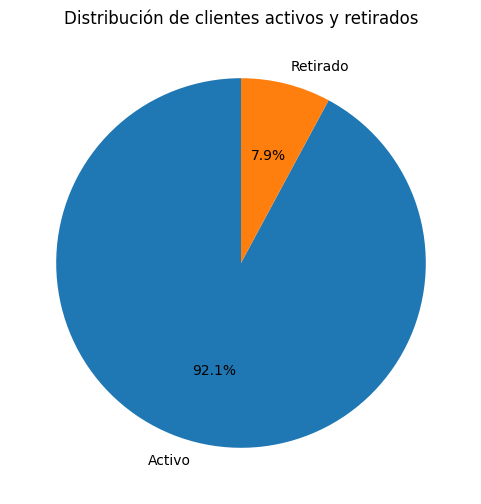

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.pie(
    churn_summary["Cantidad"],
    labels=churn_summary["Estado"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribución de clientes activos y retirados")

plt.show()

In [41]:
# Unir la información de clientes con el estado de abandono

customer_data = customer_info.merge(
    churn_labels,
    on="CustomerID",
    how="inner"
)

print("Tamaño del dataset:", customer_data.shape)

Tamaño del dataset: (10000, 8)


cada cliente ya tiene su información y su estado de abandono en la misma tabla.

In [42]:
# Abandono según tipo de contrato

contract_churn = pd.crosstab(
    customer_data["ContractType"],
    customer_data["Churn"]
)

display(contract_churn)

Churn,0,1
ContractType,,
Monthly,3654,299
Prepaid,3731,310
Yearly,1829,177


In [43]:
# Calcular el porcentaje de abandono dentro de cada tipo de contrato

contract_churn_pct = pd.crosstab(
    customer_data["ContractType"],
    customer_data["Churn"],
    normalize="index"
) * 100

contract_churn_pct = contract_churn_pct.round(2)

display(contract_churn_pct)

Churn,0,1
ContractType,,
Monthly,92.44,7.56
Prepaid,92.33,7.67
Yearly,91.18,8.82


Por ahora, podemos describir que:

Monthly: 7,56% de sus clientes se retiraron.

Prepaid: 7,67% se retiraron.

Yearly: 8,82% se retiraron.

In [44]:
# Porcentaje de clientes retirados según tipo de contrato

retired_by_contract = contract_churn_pct[1].reset_index()

retired_by_contract.columns = ["ContractType", "ChurnPercentage"]

retired_by_contract

,ContractType,ChurnPercentage
0,Monthly,7.56
1,Prepaid,7.67
2,Yearly,8.82


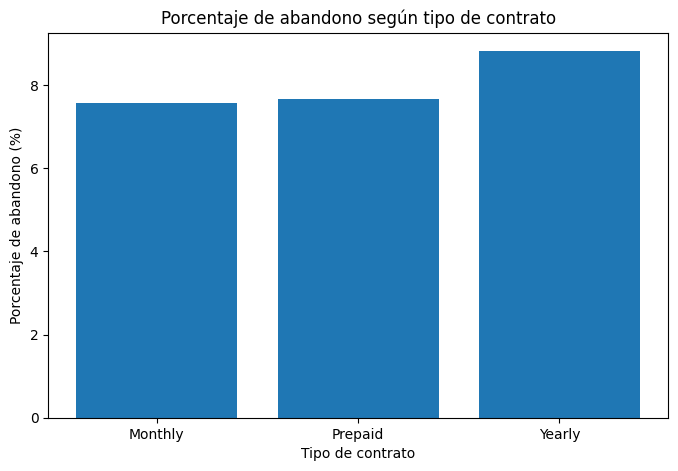

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    retired_by_contract["ContractType"],
    retired_by_contract["ChurnPercentage"]
)

plt.title("Porcentaje de abandono según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Porcentaje de abandono (%)")

plt.show()

In [46]:
# Abandono según región

region_churn = pd.crosstab(
    customer_data["Region"],
    customer_data["Churn"]
)

display(region_churn)

Churn,0,1
Region,,
Rural,3066,245
Suburban,3128,274
Urban,3020,267


In [47]:
# Calcular el porcentaje de abandono dentro de cada región

region_churn_pct = pd.crosstab(
    customer_data["Region"],
    customer_data["Churn"],
    normalize="index"
) * 100

region_churn_pct = region_churn_pct.round(2)

display(region_churn_pct)

Churn,0,1
Region,,
Rural,92.60,7.40
Suburban,91.95,8.05
Urban,91.88,8.12


Descriptivamente, la tasa de abandono es:

Rural: 7,40%

Suburban: 8,05%

Urban: 8,12%

La diferencia entre Rural y Urban es de aproximadamente 0,72 puntos porcentuales.

Esto da otro posible patrón para investigar, pero todavía no sabemos si la región realmente está asociada al abandono o si la diferencia puede deberse a variación aleatoria. Más adelante se puede comprobar estadísticamente.

In [48]:
# Obtener solamente el porcentaje de clientes retirados por región

retired_by_region = region_churn_pct[1].reset_index()

retired_by_region.columns = ["Region", "ChurnPercentage"]

display(retired_by_region)

,Region,ChurnPercentage
0,Rural,7.40
1,Suburban,8.05
2,Urban,8.12


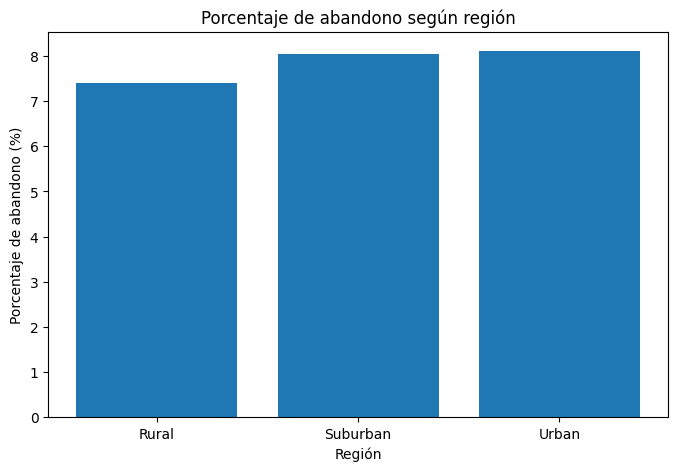

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    retired_by_region["Region"],
    retired_by_region["ChurnPercentage"]
)

plt.title("Porcentaje de abandono según región")
plt.xlabel("Región")
plt.ylabel("Porcentaje de abandono (%)")

plt.show()

In [50]:
# Edad promedio según estado del cliente

age_by_churn = customer_data.groupby("Churn")["Age"].mean().round(2)

display(age_by_churn)

,Age
Churn,
0,43.25
1,43.55


Clientes activos (Churn = 0): edad promedio 43.25 años

Clientes retirados (Churn = 1): edad promedio 43.55 años

In [51]:
# Crear rangos de edad

customer_data["AgeGroup"] = pd.cut(
    customer_data["Age"],
    bins=[17, 30, 40, 50, 60, 70],
    labels=["18-30", "31-40", "41-50", "51-60", "61-70"]
)

display(customer_data["AgeGroup"].value_counts().sort_index())

,count
AgeGroup,
18-30,1618
31-40,1278
41-50,4758
51-60,1206
61-70,1140


In [52]:
# Calcular el porcentaje de abandono dentro de cada rango de edad

age_churn_pct = pd.crosstab(
    customer_data["AgeGroup"],
    customer_data["Churn"],
    normalize="index"
) * 100

age_churn_pct = age_churn_pct.round(2)

display(age_churn_pct)

Churn,0,1
AgeGroup,,
18-30,92.77,7.23
31-40,92.02,7.98
41-50,91.91,8.09
51-60,92.12,7.88
61-70,92.37,7.63


la edad no muestra una diferencia grande en las tasas de abandono

In [53]:
# Preparar los datos para el gráfico

retired_by_age = age_churn_pct[1].reset_index()

retired_by_age.columns = ["AgeGroup", "ChurnPercentage"]

display(retired_by_age)

,AgeGroup,ChurnPercentage
0,18-30,7.23
1,31-40,7.98
2,41-50,8.09
3,51-60,7.88
4,61-70,7.63


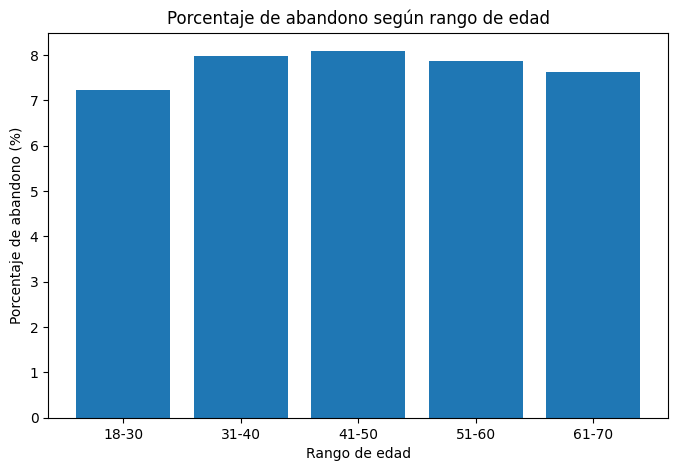

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    retired_by_age["AgeGroup"],
    retired_by_age["ChurnPercentage"]
)

plt.title("Porcentaje de abandono según rango de edad")
plt.xlabel("Rango de edad")
plt.ylabel("Porcentaje de abandono (%)")

plt.show()

El análisis del abandono según tipo de contrato, región y rango de edad muestra que las diferencias entre los grupos son relativamente pequeñas. En cuanto al contrato, el porcentaje de abandono varía entre 7.56% y 8.82%, siendo los clientes con contrato anual quienes presentan el porcentaje más alto. Por región, el abandono se encuentra entre 7.40% y 8.12%, mientras que por edad varía entre 7.23% y 8.09%.

En conjunto, estas tres variables no presentan diferencias suficientemente marcadas como para explicar por sí solas el abandono de clientes. Por esta razón, para profundizar en las causas del churn será necesario analizar variables relacionadas directamente con el comportamiento y uso del servicio, como llamadas, consumo de datos, SMS y número de quejas.

In [56]:
# Revisar los meses disponibles

usage_data["Month"].value_counts().sort_index()

,count
Month,
2023-01-31,10000
2023-02-28,10000
2023-03-31,10000
2023-04-30,10000
2023-05-31,10000
2023-06-30,10000
2023-07-31,10000
2023-08-31,10000
2023-09-30,10000


Tenemos 12 meses completos, de enero a diciembre de 2023.
Cada mes tiene exactamente 10.000 registros.
Como tenemos 10.000 clientes, aparentemente cada cliente tiene información para los 12 meses.

In [57]:
# Comportamiento promedio de los clientes por mes

monthly_usage = usage_data.groupby("Month")[
    ["CallMinutes", "DataUsageGB", "SMSCount", "Complaints"]
].mean().round(2)

display(monthly_usage)

,CallMinutes,DataUsageGB,SMSCount,Complaints
Month,,,,
2023-01-31,499.15,9.99,24.59,0.51
2023-02-28,497.99,10.01,24.36,0.50
2023-03-31,497.75,10.02,24.59,0.51
2023-04-30,498.70,9.95,24.55,0.50
2023-05-31,499.19,10.02,24.61,0.50
2023-06-30,499.10,10.04,24.60,0.51
2023-07-31,499.31,9.99,24.66,0.49
2023-08-31,497.88,10.05,24.32,0.50
2023-09-30,498.82,9.97,24.50,0.50


Hasta septiembre, el comportamiento promedio es bastante estable. Pero en octubre, noviembre y diciembre vemos un cambio claro:

CallMinutes: pasa de ~499 a ~473–474 minutos.

DataUsageGB: pasa de ~10.0 a ~9.5–9.6 GB.

SMSCount: prácticamente no cambia.

Complaints: prácticamente no cambia.

 Hay una disminución del consumo en los últimos tres meses del año, especialmente en llamadas y datos.

In [58]:
# Comparar las llamadas promedio según estado del cliente

calls_by_churn = usage_data.merge(
    churn_labels,
    on="CustomerID",
    how="inner"
).groupby(["Month", "Churn"])["CallMinutes"].mean().round(2)

display(calls_by_churn)

Month       Churn
2023-01-31  0        498.81
            1        503.20
2023-02-28  0        497.85
            1        499.61
2023-03-31  0        497.67
            1        498.58
2023-04-30  0        498.58
            1        500.09
2023-05-31  0        499.02
            1        501.15
2023-06-30  0        498.90
            1        501.40
2023-07-31  0        499.18
            1        500.85
2023-08-31  0        497.64
            1        500.69
2023-09-30  0        498.71
            1        500.13
2023-10-31  0        472.74
            1        480.77
2023-11-30  0        473.88
            1        475.67
2023-12-31  0        473.36
            1        475.80
Name: CallMinutes, dtype: float64

Los clientes que abandonaron (Churn = 1) no tenían menos llamadas que los activos.

Enero: retirados 503.20 vs activos 498.81

Junio: retirados 501.40 vs activos 498.90

Septiembre: retirados 500.13 vs activos 498.71

Octubre: retirados 480.77 vs activos 472.74

Diciembre: retirados 475.80 vs activos 473.36

In [59]:
# Comparar el consumo de datos según estado del cliente

data_by_churn = usage_data.merge(
    churn_labels,
    on="CustomerID",
    how="inner"
).groupby(["Month", "Churn"])["DataUsageGB"].mean().round(2)

display(data_by_churn)

Month       Churn
2023-01-31  0        10.00
            1         9.87
2023-02-28  0         9.99
            1        10.17
2023-03-31  0        10.02
            1         9.98
2023-04-30  0         9.95
            1         9.95
2023-05-31  0        10.02
            1         9.97
2023-06-30  0        10.03
            1        10.07
2023-07-31  0         9.98
            1        10.02
2023-08-31  0        10.06
            1         9.91
2023-09-30  0         9.99
            1         9.81
2023-10-31  0         9.60
            1         9.74
2023-11-30  0         9.52
            1         9.53
2023-12-31  0         9.64
            1         9.49
Name: DataUsageGB, dtype: float64

Aui tampoco se evidencia una diferencia clara y constante entre activos y retirados.

Enero: activos 10.00 GB vs retirados 9.87 GB

Junio: activos 10.03 GB vs retirados 10.07 GB

Septiembre: activos 9.99 GB vs retirados 9.81 GB

Diciembre: activos 9.64 GB vs retirados 9.49 GB

In [60]:
# Comparar las quejas promedio según estado del cliente

complaints_by_churn = usage_data.merge(
    churn_labels,
    on="CustomerID",
    how="inner"
).groupby("Churn")["Complaints"].mean().round(2)

display(complaints_by_churn)

,Complaints
Churn,
0,0.50
1,0.51


Hasta aqui podemos concluir que el abandono no esta claramente diferenciado por edad, región, contrato, llamadas, consumo de datos o número promedio de quejas cuando cada variable se analiza de manera individual.

In [61]:
# Calcular el promedio de uso de cada cliente

customer_usage = usage_data.groupby("CustomerID")[
    ["CallMinutes", "DataUsageGB", "SMSCount", "Complaints"]
].mean().round(2)

display(customer_usage.head())

,CallMinutes,DataUsageGB,SMSCount,Complaints
CustomerID,,,,
CUST_0,492.23,9.80,25.00,0.58
CUST_1,452.01,10.30,34.58,1.08
CUST_10,628.35,8.60,23.08,1.00
CUST_100,534.54,9.59,29.00,0.42
CUST_1000,493.88,10.91,26.25,1.00


In [62]:
# Unir el comportamiento de uso con la información de los clientes

customer_data = customer_data.merge(
    customer_usage,
    on="CustomerID",
    how="inner"
)

print("Tamaño del dataset:", customer_data.shape)

display(customer_data.head())

Tamaño del dataset: (10000, 13)


,CustomerID,Age,Gender,Region,ContractType,MonthlyCharges,SignupDate,Churn,AgeGroup,CallMinutes,DataUsageGB,SMSCount,Complaints
0,CUST_0,43.0,Male,Urban,Yearly,48.18,2021-03-20,0,41-50,492.23,9.80,25.00,0.58
1,CUST_1,43.0,Female,Suburban,Prepaid,38.94,2020-01-25,0,41-50,452.01,10.30,34.58,1.08
2,CUST_2,46.0,Female,Rural,Monthly,48.56,2022-08-31,0,41-50,578.36,8.78,26.25,0.50
3,CUST_3,43.0,Female,Urban,Prepaid,24.22,2018-12-09,0,41-50,608.48,11.12,25.92,0.50
4,CUST_4,60.0,Male,Rural,Monthly,67.86,2022-12-28,0,51-60,587.02,9.55,19.08,0.50


In [63]:
# Comparar el comportamiento promedio según estado del cliente

usage_by_churn = customer_data.groupby("Churn")[
    ["CallMinutes", "DataUsageGB", "SMSCount", "Complaints"]
].mean().round(2)

display(usage_by_churn)

,CallMinutes,DataUsageGB,SMSCount,Complaints
Churn,,,,
0,492.20,9.90,24.50,0.50
1,494.83,9.88,24.84,0.51


In [64]:
# Obtener el comportamiento de cada cliente en el último mes

last_month = usage_data[
    usage_data["Month"] == usage_data["Month"].max()
]

last_month = last_month[
    ["CustomerID", "CallMinutes", "DataUsageGB", "SMSCount", "Complaints"]
]

display(last_month.head())

,CustomerID,CallMinutes,DataUsageGB,SMSCount,Complaints
11,CUST_0,459.99,11.21,10,0
23,CUST_1,467.81,4.33,40,1
35,CUST_2,597.84,13.44,26,0
47,CUST_3,596.96,6.79,29,1
59,CUST_4,623.74,12.90,9,0


In [65]:
# Comparar el comportamiento del último mes según estado del cliente

last_month_churn = last_month.merge(
    churn_labels,
    on="CustomerID",
    how="inner"
)

last_month_by_churn = last_month_churn.groupby("Churn")[
    ["CallMinutes", "DataUsageGB", "SMSCount", "Complaints"]
].mean().round(2)

display(last_month_by_churn)

,CallMinutes,DataUsageGB,SMSCount,Complaints
Churn,,,,
0,473.36,9.64,24.48,0.50
1,475.80,9.49,24.85,0.52


El abandono no parece estar explicado por una sola característica del cliente. Las variables demográficas, contractuales y los niveles promedio de uso presentan diferencias pequeñas entre clientes activos y clientes que abandonaron. Por ello, será necesario combinar varias características para identificar patrones asociados al churn y posteriormente construir el modelo predictivo.

In [74]:
# Calcular la probabilidad histórica de abandono

probabilidad_abandono = churn_labels["Churn"].mean()

print(
    "Probabilidad histórica de abandono:",
    round(probabilidad_abandono * 100, 2),
    "%"
)

Probabilidad histórica de abandono: 7.86 %


Tenemos una tasa histórica de abandono de 7,86%. Como nuestros modelos no encontraron una característica que permita separar de forma confiable a los clientes con mayor riesgo, esta tasa general es nuestra mejor referencia para estimar el próximo ciclo, siempre que las condiciones se mantengan similares.

In [75]:
# Estimar cuántos clientes podrían abandonar en el próximo ciclo

total_clientes = len(churn_labels)

clientes_estimados_abandono = round(
    total_clientes * probabilidad_abandono
)

clientes_estimados_activos = total_clientes - clientes_estimados_abandono

print("Total de clientes:", total_clientes)
print("Clientes estimados que podrían abandonar:", clientes_estimados_abandono)
print("Clientes estimados que podrían permanecer:", clientes_estimados_activos)

Total de clientes: 10000
Clientes estimados que podrían abandonar: 786
Clientes estimados que podrían permanecer: 9214


tenemos:

10.000 clientes

786 abandonos históricos

7,86% de tasa de abandono

9.214 clientes permanecieron

Y como comprobamos que ninguna de las características disponibles permite diferenciar suficientemente a quienes abandonan, no sería correcto decir que podemos predecir qué cliente abandonará. Lo que sí podemos estimar es el nivel de abandono esperado si las condiciones se mantienen similares.

In [77]:
# Comparar la tasa de abandono según el tipo de contrato

tasa_contrato = pd.crosstab(
    customer_data["ContractType"],
    customer_data["Churn"],
    normalize="index"
) * 100

tasa_contrato = tasa_contrato.round(2)

tasa_contrato.columns = ["Activo", "Abandono"]

display(tasa_contrato)

,Activo,Abandono
ContractType,,
Monthly,92.44,7.56
Prepaid,92.33,7.67
Yearly,91.18,8.82


La diferencia entre contratos existe, pero es pequeña: incluso el grupo con mayor abandono, Yearly (8,82%), solo está 1,26 puntos porcentuales por encima de Monthly (7,56%). No es suficiente para decir que el tipo de contrato explique por sí solo el churn.


In [78]:
# Revisar los meses disponibles

print(usage_data["Month"].value_counts().sort_index())

Month
2023-01-31    10000
2023-02-28    10000
2023-03-31    10000
2023-04-30    10000
2023-05-31    10000
2023-06-30    10000
2023-07-31    10000
2023-08-31    10000
2023-09-30    10000
2023-10-31    10000
2023-11-30    10000
2023-12-31    10000
Name: count, dtype: int64


In [79]:
# Calcular el promedio mensual de uso

uso_mensual = usage_data.groupby("Month")[
    ["CallMinutes", "DataUsageGB", "SMSCount", "Complaints"]
].mean().round(2)

display(uso_mensual)

,CallMinutes,DataUsageGB,SMSCount,Complaints
Month,,,,
2023-01-31,499.15,9.99,24.59,0.51
2023-02-28,497.99,10.01,24.36,0.50
2023-03-31,497.75,10.02,24.59,0.51
2023-04-30,498.70,9.95,24.55,0.50
2023-05-31,499.19,10.02,24.61,0.50
2023-06-30,499.10,10.04,24.60,0.51
2023-07-31,499.31,9.99,24.66,0.49
2023-08-31,497.88,10.05,24.32,0.50
2023-09-30,498.82,9.97,24.50,0.50


Enero–septiembre: llamadas alrededor de 498–499 min y datos alrededor de 10 GB.
Octubre: llamadas bajan a 473,37 min y datos a 9,61 GB.
Noviembre: 474,02 min y 9,52 GB.
Diciembre: 473,55 min y 9,62 GB.

Es decir, sí existe una caída clara en llamadas y consumo de datos durante los últimos tres meses.

In [80]:
# Comparar el promedio de uso antes y durante los últimos 3 meses

antes_octubre = uso_mensual.loc[
    uso_mensual.index < "2023-10-01"
].mean()

ultimos_3_meses = uso_mensual.loc[
    uso_mensual.index >= "2023-10-01"
].mean()

comparacion = pd.DataFrame({
    "Antes de octubre": antes_octubre,
    "Últimos 3 meses": ultimos_3_meses
}).round(2)

display(comparacion)

,Antes de octubre,Últimos 3 meses
CallMinutes,498.65,473.65
DataUsageGB,10.00,9.58
SMSCount,24.53,24.51
Complaints,0.50,0.50


CallMinutes: de 498,65 → 473,65 min → caída de 25 minutos, aproximadamente 5,0%.

DataUsageGB: de 10,00 → 9,58 GB → caída de 0,42 GB, aproximadamente 4,2%.

SMS: prácticamente sin cambio.

Quejas: prácticamente sin cambio.

Conclusión del análisis temporal

Durante los últimos tres meses se observa una disminución clara en llamadas y consumo de datos, mientras que SMS y quejas permanecen estables. Este cambio de comportamiento debe ser monitoreado, aunque con los datos disponibles no podemos afirmar que sea la causa del abandono.

In [81]:
# Preparar los datos mensuales para las gráficas

uso_mensual = uso_mensual.reset_index()

uso_mensual["Month"] = pd.to_datetime(uso_mensual["Month"])

uso_mensual["Mes"] = uso_mensual["Month"].dt.strftime("%b")

display(uso_mensual)

,Month,CallMinutes,DataUsageGB,SMSCount,Complaints,Mes
0,2023-01-31,499.15,9.99,24.59,0.51,Jan
1,2023-02-28,497.99,10.01,24.36,0.50,Feb
2,2023-03-31,497.75,10.02,24.59,0.51,Mar
3,2023-04-30,498.70,9.95,24.55,0.50,Apr
4,2023-05-31,499.19,10.02,24.61,0.50,May
5,2023-06-30,499.10,10.04,24.60,0.51,Jun
6,2023-07-31,499.31,9.99,24.66,0.49,Jul
7,2023-08-31,497.88,10.05,24.32,0.50,Aug
8,2023-09-30,498.82,9.97,24.50,0.50,Sep
9,2023-10-31,473.37,9.61,24.46,0.51,Oct


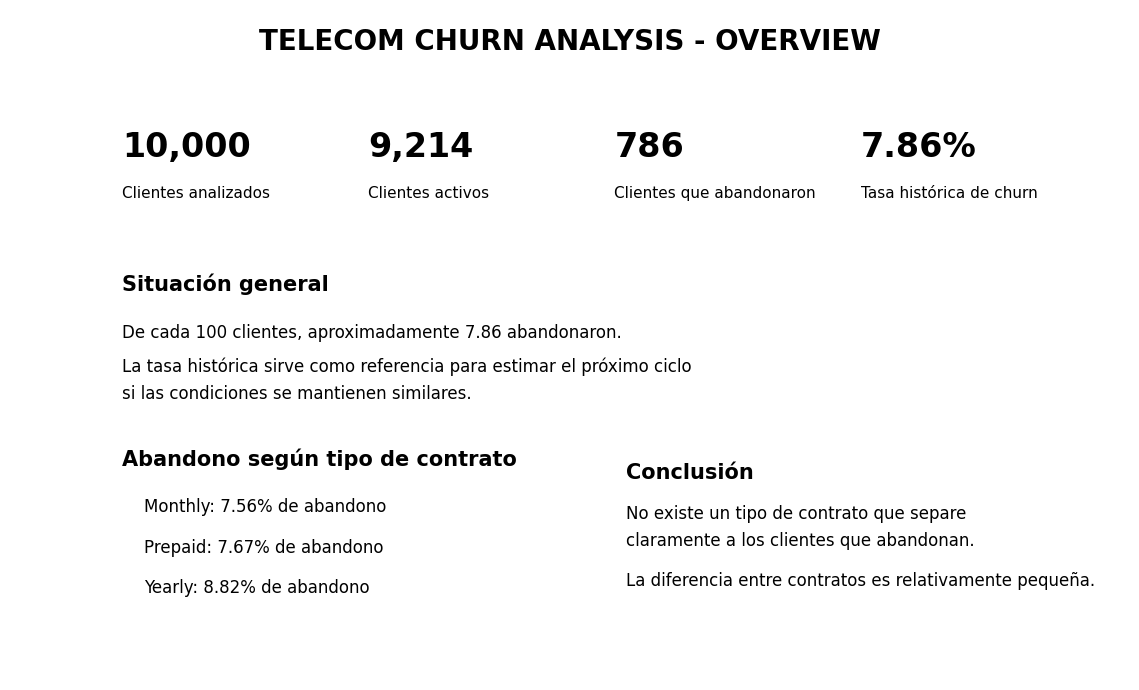

In [82]:
# Dashboard 1 - Overview

import matplotlib.pyplot as plt

# Datos principales
total_clientes = len(customer_data)
clientes_activos = (customer_data["Churn"] == 0).sum()
clientes_abandono = (customer_data["Churn"] == 1).sum()
tasa_abandono = clientes_abandono / total_clientes * 100

# Tasa de abandono por contrato
tasa_contrato = pd.crosstab(
    customer_data["ContractType"],
    customer_data["Churn"],
    normalize="index"
) * 100

tasa_contrato = tasa_contrato.round(2)

# Crear dashboard
fig, ax = plt.subplots(figsize=(12, 7))

ax.axis("off")

# Título
ax.text(
    0.5, 0.94,
    "TELECOM CHURN ANALYSIS - OVERVIEW",
    ha="center",
    fontsize=20,
    fontweight="bold"
)

# Indicadores
ax.text(0.10, 0.78, f"{total_clientes:,}",
        fontsize=24, fontweight="bold")
ax.text(0.10, 0.72, "Clientes analizados",
        fontsize=11)

ax.text(0.32, 0.78, f"{clientes_activos:,}",
        fontsize=24, fontweight="bold")
ax.text(0.32, 0.72, "Clientes activos",
        fontsize=11)

ax.text(0.54, 0.78, f"{clientes_abandono:,}",
        fontsize=24, fontweight="bold")
ax.text(0.54, 0.72, "Clientes que abandonaron",
        fontsize=11)

ax.text(0.76, 0.78, f"{tasa_abandono:.2f}%",
        fontsize=24, fontweight="bold")
ax.text(0.76, 0.72, "Tasa histórica de churn",
        fontsize=11)

# Resumen
ax.text(
    0.10, 0.58,
    "Situación general",
    fontsize=15,
    fontweight="bold"
)

ax.text(
    0.10, 0.51,
    f"De cada 100 clientes, aproximadamente {tasa_abandono:.2f} abandonaron.",
    fontsize=12
)

ax.text(
    0.10, 0.46,
    "La tasa histórica sirve como referencia para estimar el próximo ciclo",
    fontsize=12
)

ax.text(
    0.10, 0.42,
    "si las condiciones se mantienen similares.",
    fontsize=12
)

# Contratos
ax.text(
    0.10, 0.32,
    "Abandono según tipo de contrato",
    fontsize=15,
    fontweight="bold"
)

y = 0.25

for contrato in tasa_contrato.index:
    abandono = tasa_contrato.loc[contrato, 1]

    ax.text(
        0.12, y,
        f"{contrato}: {abandono:.2f}% de abandono",
        fontsize=12
    )

    y -= 0.06

# Conclusión
ax.text(
    0.55, 0.30,
    "Conclusión",
    fontsize=15,
    fontweight="bold"
)

ax.text(
    0.55, 0.24,
    "No existe un tipo de contrato que separe",
    fontsize=12
)

ax.text(
    0.55, 0.20,
    "claramente a los clientes que abandonan.",
    fontsize=12
)

ax.text(
    0.55, 0.14,
    "La diferencia entre contratos es relativamente pequeña.",
    fontsize=12
)

plt.tight_layout()

# Guardar dashboard
plt.savefig(
    "dashboard_overview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

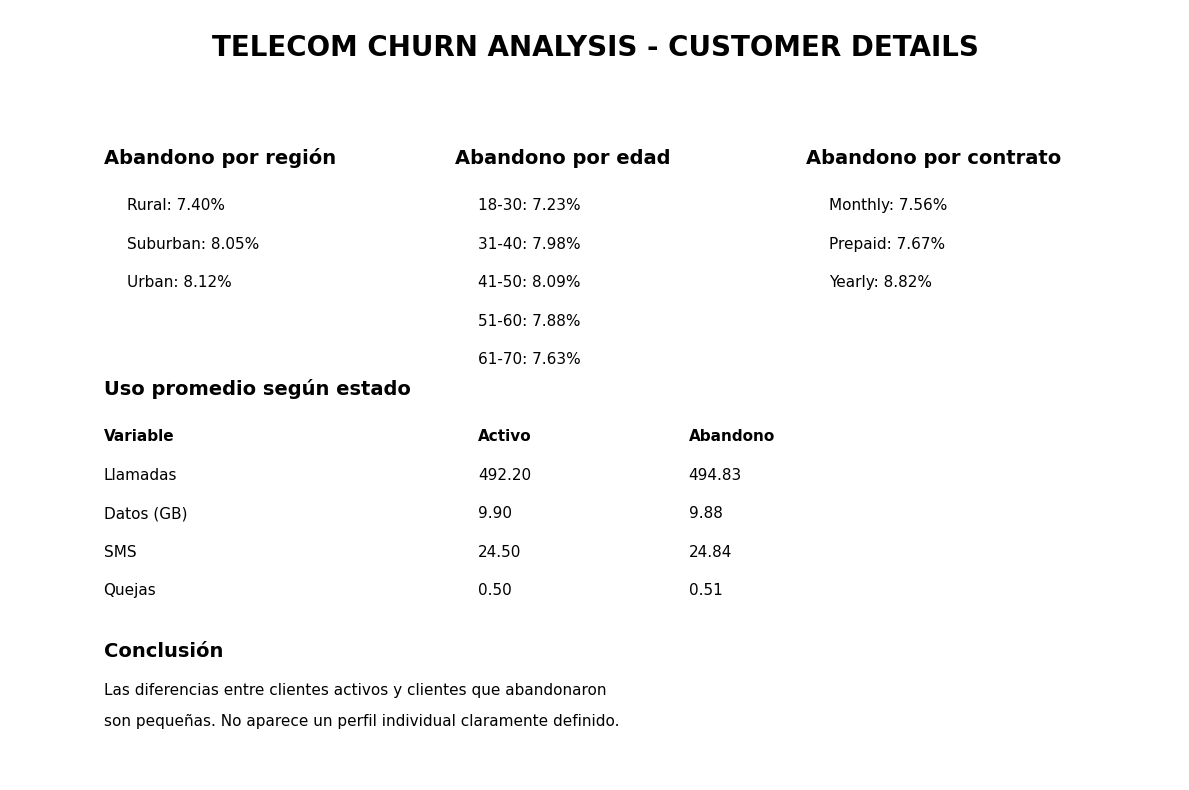

In [83]:
# Dashboard 2 - Datos específicos

# Crear grupos de edad para el dashboard
customer_data["AgeGroup"] = pd.cut(
    customer_data["Age"],
    bins=[17, 30, 40, 50, 60, 70],
    labels=["18-30", "31-40", "41-50", "51-60", "61-70"]
)

# Calcular tasas de abandono
tasa_region = pd.crosstab(
    customer_data["Region"],
    customer_data["Churn"],
    normalize="index"
) * 100

tasa_edad = pd.crosstab(
    customer_data["AgeGroup"],
    customer_data["Churn"],
    normalize="index"
) * 100

tasa_contrato = pd.crosstab(
    customer_data["ContractType"],
    customer_data["Churn"],
    normalize="index"
) * 100

# Promedios de uso según abandono
uso_churn = customer_data.groupby("Churn")[
    ["CallMinutes", "DataUsageGB", "SMSCount", "Complaints"]
].mean().round(2)

# Crear dashboard
fig, ax = plt.subplots(figsize=(12, 8))

ax.axis("off")

# Título
ax.text(
    0.5, 0.94,
    "TELECOM CHURN ANALYSIS - CUSTOMER DETAILS",
    ha="center",
    fontsize=20,
    fontweight="bold"
)

# Región
ax.text(
    0.08, 0.80,
    "Abandono por región",
    fontsize=14,
    fontweight="bold"
)

y = 0.74

for region in tasa_region.index:
    abandono = tasa_region.loc[region, 1]

    ax.text(
        0.10, y,
        f"{region}: {abandono:.2f}%",
        fontsize=11
    )

    y -= 0.05

# Edad
ax.text(
    0.38, 0.80,
    "Abandono por edad",
    fontsize=14,
    fontweight="bold"
)

y = 0.74

for edad in tasa_edad.index:
    abandono = tasa_edad.loc[edad, 1]

    ax.text(
        0.40, y,
        f"{edad}: {abandono:.2f}%",
        fontsize=11
    )

    y -= 0.05

# Contrato
ax.text(
    0.68, 0.80,
    "Abandono por contrato",
    fontsize=14,
    fontweight="bold"
)

y = 0.74

for contrato in tasa_contrato.index:
    abandono = tasa_contrato.loc[contrato, 1]

    ax.text(
        0.70, y,
        f"{contrato}: {abandono:.2f}%",
        fontsize=11
    )

    y -= 0.05

# Uso promedio
ax.text(
    0.08, 0.50,
    "Uso promedio según estado",
    fontsize=14,
    fontweight="bold"
)

ax.text(
    0.08, 0.44,
    "Variable",
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.40, 0.44,
    "Activo",
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.58, 0.44,
    "Abandono",
    fontsize=11,
    fontweight="bold"
)

variables = {
    "CallMinutes": "Llamadas",
    "DataUsageGB": "Datos (GB)",
    "SMSCount": "SMS",
    "Complaints": "Quejas"
}

y = 0.39

for variable, nombre in variables.items():

    activo = uso_churn.loc[0, variable]
    abandono = uso_churn.loc[1, variable]

    ax.text(0.08, y, nombre, fontsize=11)
    ax.text(0.40, y, f"{activo:.2f}", fontsize=11)
    ax.text(0.58, y, f"{abandono:.2f}", fontsize=11)

    y -= 0.05

# Conclusión
ax.text(
    0.08, 0.16,
    "Conclusión",
    fontsize=14,
    fontweight="bold"
)

ax.text(
    0.08, 0.11,
    "Las diferencias entre clientes activos y clientes que abandonaron",
    fontsize=11
)

ax.text(
    0.08, 0.07,
    "son pequeñas. No aparece un perfil individual claramente definido.",
    fontsize=11
)

plt.tight_layout()

# Guardar dashboard
plt.savefig(
    "dashboard_detail.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

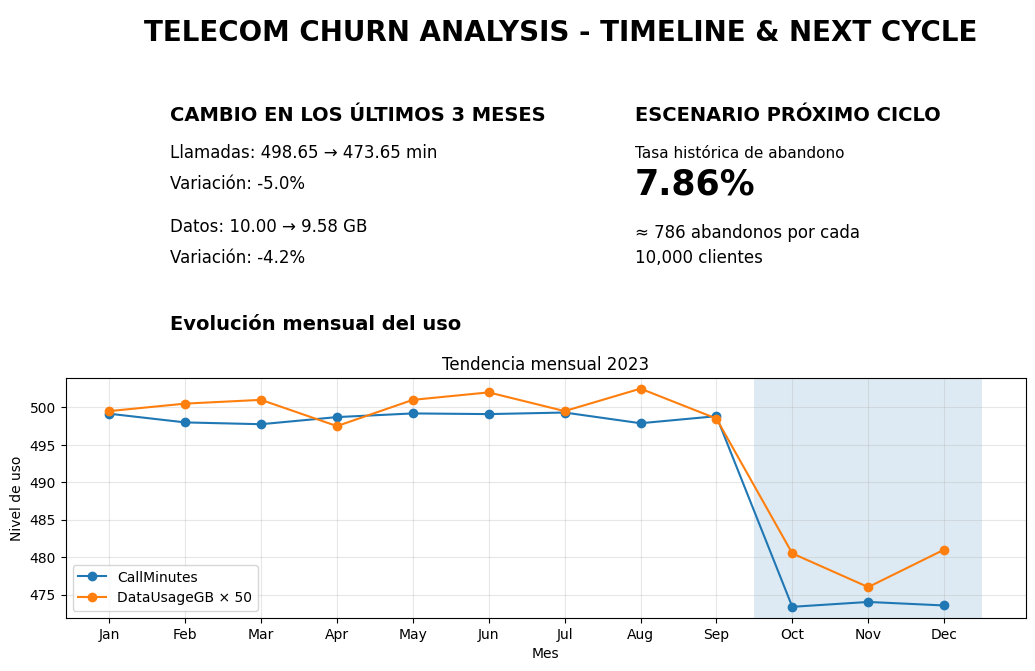

In [84]:
# Dashboard 3 - Línea de tiempo y próximo ciclo

# Calcular promedios antes de octubre y últimos 3 meses

antes_octubre = uso_mensual.loc[
    uso_mensual["Month"] < "2023-10-01"
].mean(numeric_only=True)

ultimos_3_meses = uso_mensual.loc[
    uso_mensual["Month"] >= "2023-10-01"
].mean(numeric_only=True)

# Calcular variación porcentual

caida_llamadas = (
    (ultimos_3_meses["CallMinutes"] - antes_octubre["CallMinutes"])
    / antes_octubre["CallMinutes"]
) * 100

caida_datos = (
    (ultimos_3_meses["DataUsageGB"] - antes_octubre["DataUsageGB"])
    / antes_octubre["DataUsageGB"]
) * 100

# Crear dashboard
fig, ax = plt.subplots(figsize=(12, 8))

ax.axis("off")

# Título
ax.text(
    0.5, 0.95,
    "TELECOM CHURN ANALYSIS - TIMELINE & NEXT CYCLE",
    ha="center",
    fontsize=20,
    fontweight="bold"
)

# Datos principales de la caída
ax.text(
    0.08, 0.82,
    "CAMBIO EN LOS ÚLTIMOS 3 MESES",
    fontsize=14,
    fontweight="bold"
)

ax.text(
    0.08, 0.76,
    f"Llamadas: {antes_octubre['CallMinutes']:.2f} → "
    f"{ultimos_3_meses['CallMinutes']:.2f} min",
    fontsize=12
)

ax.text(
    0.08, 0.71,
    f"Variación: {caida_llamadas:.1f}%",
    fontsize=12
)

ax.text(
    0.08, 0.64,
    f"Datos: {antes_octubre['DataUsageGB']:.2f} → "
    f"{ultimos_3_meses['DataUsageGB']:.2f} GB",
    fontsize=12
)

ax.text(
    0.08, 0.59,
    f"Variación: {caida_datos:.1f}%",
    fontsize=12
)

# Escenario siguiente ciclo
ax.text(
    0.58, 0.82,
    "ESCENARIO PRÓXIMO CICLO",
    fontsize=14,
    fontweight="bold"
)

ax.text(
    0.58, 0.76,
    "Tasa histórica de abandono",
    fontsize=11
)

ax.text(
    0.58, 0.70,
    "7.86%",
    fontsize=25,
    fontweight="bold"
)

ax.text(
    0.58, 0.63,
    "≈ 786 abandonos por cada",
    fontsize=12
)

ax.text(
    0.58, 0.59,
    "10,000 clientes",
    fontsize=12
)

# Línea temporal
ax.text(
    0.08, 0.48,
    "Evolución mensual del uso",
    fontsize=14,
    fontweight="bold"
)

# Crear un eje para la gráfica
chart_ax = fig.add_axes([0.10, 0.12, 0.80, 0.30])

chart_ax.plot(
    uso_mensual["Mes"],
    uso_mensual["CallMinutes"],
    marker="o",
    label="CallMinutes"
)

chart_ax.plot(
    uso_mensual["Mes"],
    uso_mensual["DataUsageGB"] * 50,
    marker="o",
    label="DataUsageGB × 50"
)

chart_ax.axvspan(
    9 - 0.5,
    11 + 0.5,
    alpha=0.15
)

chart_ax.set_title("Tendencia mensual 2023")
chart_ax.set_xlabel("Mes")
chart_ax.set_ylabel("Nivel de uso")
chart_ax.legend()

chart_ax.grid(True, alpha=0.3)

# Nota
ax.text(
    0.10, 0.04,
    "Nota: la tasa de 7.86% es una referencia histórica y no una predicción individual.",
    fontsize=9
)

plt.savefig(
    "dashboard_timeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()